# Lecture 7

## Exercise 1
- Simulate the stock market according to the Markov Chain rule. 
  Start from a random state and simulate many many iterations. 
- Implement a pure-python version and a numba version, and compare speeds.

In [ ]:
import numpy as np
from numba import njit
from collections import Counter
import time

# Functions -------------------------------------------------------------------

# -------------------------------- Pure-python --------------------------------
# Generates next state of the market
def step_python(current_state):
    
    prob_rand = np.random.random()
    prob_cumulative = 0

    for idx_state, prob in enumerate(P[current_state]):    
        prob_cumulative += prob

        if prob_rand < prob_cumulative:
            return idx_state
                 

# Simulates all the states undergone by the market
def simul_python(N_step):

    current_state = np.random.randint(0,3) # random initial state
    state_list = []
    state_list.append(current_state)

    for _ in range(N_step-1):
        current_state = step_python(current_state)
        state_list.append(current_state)

    return state_list


# -------------------------------- Numba --------------------------------
@njit
def step_numba(current_state):

    prob_rand = np.random.random()
    prob_cumulative = 0

    for idx_state, prob in enumerate(P[current_state]):    
        prob_cumulative += prob

        if prob_rand < prob_cumulative:
            return idx_state
        
    return np.random.randint(0,3)   # should never happen, added to avoid numba issues

@njit
def simul_numba(N_step):

    current_state = np.random.randint(0,3) # random initial state
    state_list = []
    state_list.append(current_state)

    for _ in range(N_step - 1):
        current_state = step_numba(current_state)
        state_list.append(current_state)

    return state_list


# MAIN ------------------------------------------------------------------------

states = ["Bull", "Bear","Recession"]

# Matrix of probabilities:
# Prob of moving from the state corrisponding to row i to the one corresponding to col j
# Indices i,j = 0 (Bull), 1 (Bear), 2 (Recession)
P = np.array([[0.90,  0.075, 0.025],
              [0.15,  0.80,  0.05 ],    
              [0.25,  0.25,  0.50 ]])

N = int(10e5)  # number of iterations

# -------------------------------- Pure-python --------------------------------

t_init = time.perf_counter()

results_python = simul_python(N)

t_fin = time.perf_counter()
t_python = t_fin - t_init

counts = Counter(results_python)

print("Pure-python version results:")
print(f"Bull: {counts[0]/N*100:.2f} %")
print(f"Bear: {counts[1]/N*100:.2f} %")
print(f"Recession: {counts[2]/N*100:.2f} %\n")

# --------------------------------- Numba -------------------------------------

# First call made to compile the function --> take into account only the execution time
simul_numba(50)

t_init = time.perf_counter()

results_numba = simul_numba(N)

t_fin = time.perf_counter()
t_numba = t_fin - t_init

counts = Counter(results_numba)

print("Numba version results:")
print(f"Bull: {counts[0]/N*100:.2f} %")
print(f"Bear: {counts[1]/N*100:.2f} %")
print(f"Recession: {counts[2]/N*100:.2f} %\n")

# Comparison python vs numba
print(f"Pure-python: execution time = {t_python:.3f} s")
print(f"Numba: execution time = {t_numba:.3f} s")
print(f"Numba version is {t_python/t_numba:.1f} times faster than pure-python version!")

```text
Pure-python version results:
Bull: 62.49 %
Bear: 31.30 %
Recession: 6.21 %

Numba version results:
Bull: 62.52 %
Bear: 31.19 %
Recession: 6.29 %

Pure-python: execution time = 1.893 s
Numba: execution time = 0.037 s
Numba version is 51.6 times faster than pure-python version!
```

## Exercise 7
Write a decorator for the plots of all your papers.
- Remember a decorator takes a function.
- This function in turn should return a matplotlib figure object.
- Before the function is called, the decorator should initialize a matplotlib figure 
  with the options that you like the most (fontsize, ticks, etc etc)
- After the figure it's done, the decorator should save it to pdf.

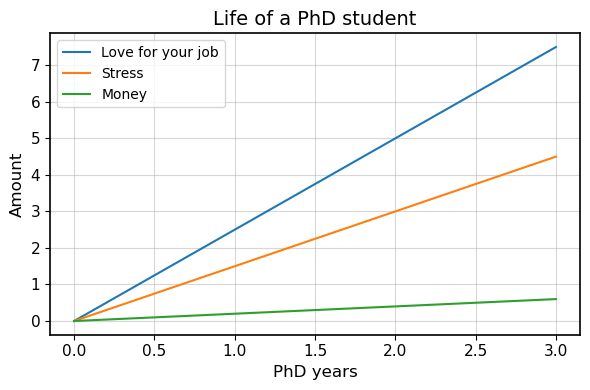

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Decorator definition
def myplot(filename, figsize=(8,5)):

    def decorator(func):

        def wrapper(*args, **kwargs):

            # global parameters
            plt.rcParams["axes.linewidth"] = 1.2
            plt.rcParams["xtick.labelsize"] = 11
            plt.rcParams["ytick.labelsize"] = 11
            plt.rcParams["axes.labelsize"] = 12
            plt.rcParams["axes.titlesize"] = 14
            plt.rcParams["legend.fontsize"] = 10

            fig, ax = plt.subplots(figsize=figsize)

            func(ax, *args, **kwargs) # create plot

            ax.grid(alpha=0.5)
            ax.legend(loc="upper left")
            plt.tight_layout()

            fig.savefig(filename)   # save pdf figure

            return fig

        return wrapper

    return decorator


# Example
@myplot("Phd_student_life.pdf", figsize=(6,4))
def phd_plot(ax):

    x = np.linspace(0, 3, 100) 
    ax.plot(x, 2.5*x , label="Love for your job")
    ax.plot(x, 1.5*x, label="Stress")
    ax.plot(x, 0.2*x, label="Money")
    ax.set_title("Life of a PhD student")
    ax.set_xlabel("PhD years")
    ax.set_ylabel("Amount")

phd_plot()
plt.show()